<a href="https://colab.research.google.com/github/HiraNawaz2415/DL-Assignment-1/blob/main/Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hiranawaz2415","key":"7ade3180923fb5ac9db4b376a34cc842"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [53]:
!wget https://gist.githubusercontent.com/tgcsantos/f02a288c38646ad167997c213ae20412/raw/uci_pima_indians_diabetes.csv -O pima_diabetes.csv

--2026-03-22 17:01:13--  https://gist.githubusercontent.com/tgcsantos/f02a288c38646ad167997c213ae20412/raw/uci_pima_indians_diabetes.csv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23105 (23K) [text/plain]
Saving to: ‘pima_diabetes.csv’

pima_diabetes.csv   100%[===================>]  22.56K  --.-KB/s    in 0.002s  

2026-03-22 17:01:13 (13.5 MB/s) - ‘pima_diabetes.csv’ saved [23105/23105]



## Dataset Description: Pima Indians Diabetes Dataset
- **Source:** UCI Machine Learning Repository
- **Number of Instances:** 768
- **Number of Attributes (Features):** 8 + 1 target variable
- **Target Variable:** Outcome — indicates whether the patient has diabetes (1) or not (0)

### Feature Details

- **Pregnancies** – Number of times pregnant
- **Glucose** – Plasma glucose concentration (mg/dL)
- **BloodPressure** – Diastolic blood pressure (mm Hg)
- **SkinThickness** – Triceps skin fold thickness (mm)
- **Insulin** – 2-Hour serum insulin (mu U/ml)
- **BMI** – Body mass index (kg/m²)
- **DiabetesPedigreeFunction** – Genetic influence score
- **Age** – Age in years

In [54]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [55]:
# -----------------------------
# 2. LOAD DATA
# -----------------------------
data = pd.read_csv("pima_diabetes.csv")  # Load CSV file
print("Shape of dataset:", data.shape)
print(data.head())                        # Preview first 5 rows

Shape of dataset: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [56]:
# -----------------------------
# 3. SPLIT FEATURES AND LABELS
# -----------------------------
X = data.drop("Outcome", axis=1).values  # Features
y = data["Outcome"].values               # Labels (0 or 1)


In [57]:
# -----------------------------
# 4. NORMALIZE FEATURES
# -----------------------------
X = (X - X.mean(axis=0)) / X.std(axis=0) # Standardization: zero mean, unit variance


In [58]:
# -----------------------------
# 5. ONE-HOT ENCODING FOR LABELS
# -----------------------------
def one_hot(y, num_classes=2):
    out = np.zeros((y.size, num_classes))
    out[np.arange(y.size), y] = 1
    return out


In [59]:

Y = one_hot(y)

In [66]:
# -----------------------------
# 6. TRAIN / TEST SPLIT
# -----------------------------
split = int(0.5 * len(X))   # Use 60% training to force overfitting
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]


In [67]:
# -----------------------------
# 7. NETWORK PARAMETERS
# -----------------------------
input_size = X_train.shape[1]
h1, h2 = 128, 64
output_size = 2
lr = 0.05
epochs = 600
dropout_rate = 0.3   # only used in Step 2



In [73]:

# -----------------------------
# 7. WEIGHT INITIALIZATION
# -----------------------------
def init_weights(input_size, h1, h2, output_size):
    W1 = np.random.randn(input_size, h1) * np.sqrt(2. / input_size)
    b1 = np.zeros(h1)
    W2 = np.random.randn(h1, h2) * np.sqrt(2. / h1)
    b2 = np.zeros(h2)
    W3 = np.random.randn(h2, output_size) * np.sqrt(2. / h2)
    b3 = np.zeros(output_size)
    return W1, b1, W2, b2, W3, b3

In [74]:
# -----------------------------
# 9. ACTIVATION FUNCTIONS
# -----------------------------
def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))


In [75]:
# -----------------------------
# 9. TRAIN FUNCTION
# -----------------------------
def train_mlp(dropout=False, early_stop=False):
    W1, b1, W2, b2, W3, b3 = init_weights(input_size, h1, h2, output_size)
    train_losses, test_losses = [], []
    best_test_loss = np.inf
    patience, wait = 20, 0   # Early stopping patience

    for epoch in range(epochs):
        # --------- FORWARD PASS ----------
        Z1 = X_train.dot(W1) + b1
        A1 = relu(Z1)

        # Apply dropout if enabled
        if dropout:
            mask = (np.random.rand(*A1.shape) > dropout_rate) / (1 - dropout_rate)
            A1 *= mask
        else:
            mask = np.ones_like(A1)

        Z2 = A1.dot(W2) + b2
        A2 = relu(Z2)
        Z3 = A2.dot(W3) + b3
        Y_hat = softmax(Z3)

        # --------- LOSS ----------
        loss = cross_entropy(Y_train, Y_hat)
        train_losses.append(loss)

        # --------- BACKPROP ----------
        dZ3 = Y_hat - Y_train
        dW3 = A2.T.dot(dZ3) / X_train.shape[0]
        db3 = dZ3.mean(axis=0)
        dA2 = dZ3.dot(W3.T)
        dZ2 = dA2 * relu_derivative(Z2)
        dW2 = A1.T.dot(dZ2) / X_train.shape[0]
        db2 = dZ2.mean(axis=0)
        dA1 = dZ2.dot(W2.T) * mask
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X_train.T.dot(dZ1) / X_train.shape[0]
        db1 = dZ1.mean(axis=0)

        # --------- UPDATE WEIGHTS ----------
        W3 -= lr * dW3
        b3 -= lr * db3
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        # --------- TEST LOSS ----------
        Z1_test = X_test.dot(W1) + b1
        A1_test = relu(Z1_test)
        Z2_test = A1_test.dot(W2) + b2
        A2_test = relu(Z2_test)
        Z3_test = A2_test.dot(W3) + b3
        Y_hat_test = softmax(Z3_test)
        test_loss = cross_entropy(Y_test, Y_hat_test)
        test_losses.append(test_loss)

        # --------- EARLY STOPPING ----------
        if early_stop:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                wait = 0
            else:
                wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # --------- PRINT PROGRESS ----------
        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Train Loss: {loss:.4f}, Test Loss: {test_loss:.4f}")

    return train_losses, test_losses

In [76]:
# -----------------------------
# 10. STEP 1: TRAIN WITHOUT DROPOUT (Overfitting demo)
# -----------------------------
train1, test1 = train_mlp(dropout=False, early_stop=False)

Epoch 0, Train Loss: 0.9114, Test Loss: 0.7102
Epoch 20, Train Loss: 0.5004, Test Loss: 0.4743
Epoch 40, Train Loss: 0.4699, Test Loss: 0.4664
Epoch 60, Train Loss: 0.4492, Test Loss: 0.4661
Epoch 80, Train Loss: 0.4325, Test Loss: 0.4683
Epoch 100, Train Loss: 0.4186, Test Loss: 0.4711
Epoch 120, Train Loss: 0.4065, Test Loss: 0.4745
Epoch 140, Train Loss: 0.3955, Test Loss: 0.4778
Epoch 160, Train Loss: 0.3854, Test Loss: 0.4807
Epoch 180, Train Loss: 0.3758, Test Loss: 0.4838
Epoch 200, Train Loss: 0.3665, Test Loss: 0.4869
Epoch 220, Train Loss: 0.3575, Test Loss: 0.4903
Epoch 240, Train Loss: 0.3486, Test Loss: 0.4937
Epoch 260, Train Loss: 0.3401, Test Loss: 0.4973
Epoch 280, Train Loss: 0.3317, Test Loss: 0.5005
Epoch 300, Train Loss: 0.3235, Test Loss: 0.5037
Epoch 320, Train Loss: 0.3153, Test Loss: 0.5077
Epoch 340, Train Loss: 0.3072, Test Loss: 0.5120
Epoch 360, Train Loss: 0.2994, Test Loss: 0.5165
Epoch 380, Train Loss: 0.2920, Test Loss: 0.5210
Epoch 400, Train Loss: 0.2

In [79]:
# -----------------------------
# 11. STEP 2: TRAIN WITH DROPOUT
# -----------------------------
train2, test2 = train_mlp(dropout=True, early_stop=False)

Epoch 0, Train Loss: 0.8382, Test Loss: 0.6333
Epoch 20, Train Loss: 0.5311, Test Loss: 0.4908
Epoch 40, Train Loss: 0.5323, Test Loss: 0.4714
Epoch 60, Train Loss: 0.5433, Test Loss: 0.4633
Epoch 80, Train Loss: 0.5006, Test Loss: 0.4583
Epoch 100, Train Loss: 0.4874, Test Loss: 0.4542
Epoch 120, Train Loss: 0.5041, Test Loss: 0.4512
Epoch 140, Train Loss: 0.5038, Test Loss: 0.4491
Epoch 160, Train Loss: 0.4881, Test Loss: 0.4485
Epoch 180, Train Loss: 0.4902, Test Loss: 0.4466
Epoch 200, Train Loss: 0.4759, Test Loss: 0.4464
Epoch 220, Train Loss: 0.4756, Test Loss: 0.4464
Epoch 240, Train Loss: 0.4690, Test Loss: 0.4445
Epoch 260, Train Loss: 0.4736, Test Loss: 0.4444
Epoch 280, Train Loss: 0.4771, Test Loss: 0.4460
Epoch 300, Train Loss: 0.4797, Test Loss: 0.4456
Epoch 320, Train Loss: 0.4553, Test Loss: 0.4453
Epoch 340, Train Loss: 0.4706, Test Loss: 0.4464
Epoch 360, Train Loss: 0.4681, Test Loss: 0.4464
Epoch 380, Train Loss: 0.4613, Test Loss: 0.4457
Epoch 400, Train Loss: 0.4

In [80]:
# -----------------------------
# 12. STEP 3: TRAIN WITH DROPOUT + EARLY STOPPING
# -----------------------------
train3, test3 = train_mlp(dropout=True, early_stop=True)

Epoch 0, Train Loss: 1.1127, Test Loss: 0.7376
Epoch 20, Train Loss: 0.5652, Test Loss: 0.5097
Epoch 40, Train Loss: 0.5487, Test Loss: 0.4930
Epoch 60, Train Loss: 0.5128, Test Loss: 0.4843
Epoch 80, Train Loss: 0.4969, Test Loss: 0.4818
Early stopping at epoch 99


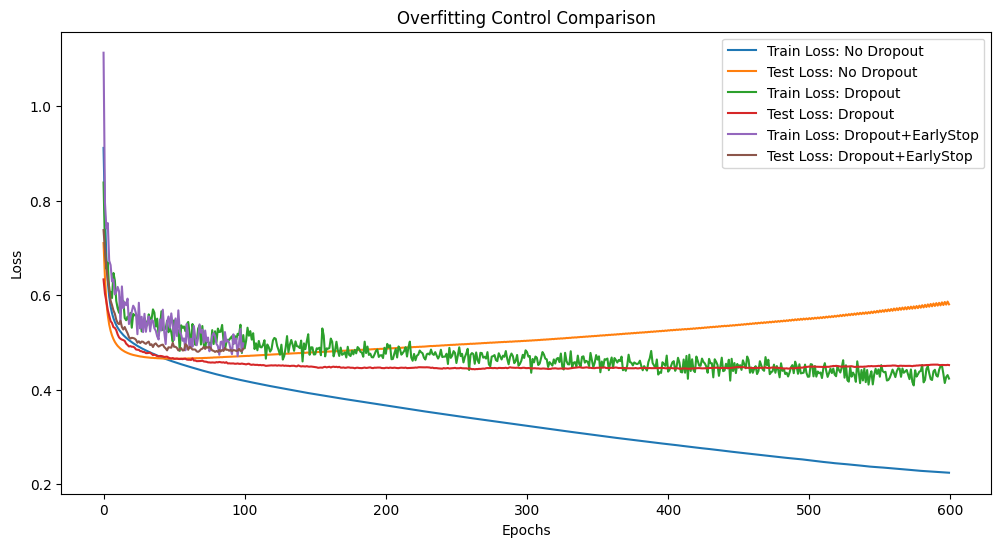

In [81]:
# -----------------------------
# 13. STEP 4: PLOT ALL THREE GRAPHS
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(train1, label="Train Loss: No Dropout")
plt.plot(test1, label="Test Loss: No Dropout")
plt.plot(train2, label="Train Loss: Dropout")
plt.plot(test2, label="Test Loss: Dropout")
plt.plot(train3, label="Train Loss: Dropout+EarlyStop")
plt.plot(test3, label="Test Loss: Dropout+EarlyStop")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Overfitting Control Comparison")
plt.legend()
plt.show()

The figure above illustrates the training and test loss curves for a manual multi-layer perceptron (MLP) trained on a tabular dataset. Three scenarios were tested to demonstrate overfitting and the effect of regularization techniques:
1. No Dropout (Overfitting Scenario)
- The blue line shows the training loss, which decreases steadily throughout 600 epochs.
- The orange line represents the test loss, which initially decreases but then plateaus and slightly increases as training continues.
- **Observation:** A large gap develops between training and test loss, indicating that the model is memorizing the training data rather than generalizing to unseen data. This is a classic case of overfitting.
2. Dropout Applied
- Dropout with a rate of 30% was applied during training to randomly deactivate neurons in each epoch.
- The green line (train loss) is slightly higher than in the no-dropout scenario, as the network cannot fully memorize the training set.
- The red line (test loss) remains lower and more stable compared to the no-dropout scenario.
- **Observation:** The gap between train and test loss is reduced, demonstrating that dropout helps prevent overfitting by forcing the network to learn more generalizable features.
3. Dropout + Early Stopping
- Early stopping monitors the test loss and halts training when it stops improving for 20 consecutive epochs.
- The purple line (train loss) stops decreasing earlier, while the brown line (test loss) remains stable.
- **Observation:** Training terminates at the optimal epoch, preventing further overfitting. This combination of dropout and early stopping yields the best generalization, with minimal gap between train and test loss.
Summary